<a href="https://colab.research.google.com/github/jiorjioo/MCS-AI/blob/main/Assignment_2_Deep_Learning_Balma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 2 Deep Learning**

**Learning Strategy on MNIST Data**

Balma Bahira Adzkia (25/572255/PPA/07189)

# SLIDE REFERENCE

In [1]:
import keras
from keras.datasets import mnist

m -> materi

In [2]:
(X_train_m, y_train_m), (X_test_m, y_test_m) = mnist.load_data()
X_train_m = X_train_m.reshape(-1, 28,28,1)
X_test_m = X_test_m.reshape(-1, 28,28,1)

In [3]:
X_train_m = X_train_m.astype('float32')
X_test_m = X_test_m.astype('float32')
X_train_m /= 255
X_test_m /= 255
y_train_m = keras.utils.to_categorical(y_train_m, 10)
y_test_m = keras.utils.to_categorical(y_test_m, 10)

In [4]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

model_m = Sequential()
model_m.add(Flatten())
model_m.add(Dense(64,activation='relu'))
model_m.add(Dense(10,activation='softmax'))

In [5]:
model_m.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['acc'])

history_m = model_m.fit(X_train_m,
                      y_train_m,
                      epochs=10,
                      batch_size=100,
                      validation_data=(X_test_m,y_test_m))
model_m.save('my_model_m.h5')
model_m.evaluate(X_test_m,y_test_m)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8915 - loss: 0.3943 - val_acc: 0.9372 - val_loss: 0.2179
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9473 - loss: 0.1868 - val_acc: 0.9528 - val_loss: 0.1629
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9590 - loss: 0.1412 - val_acc: 0.9581 - val_loss: 0.1353
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9664 - loss: 0.1140 - val_acc: 0.9621 - val_loss: 0.1238
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9719 - loss: 0.0961 - val_acc: 0.9661 - val_loss: 0.1104
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9750 - loss: 0.0829 - val_acc: 0.9685 - val_loss: 0.1027
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9784 - loss: 0.0728 - val_acc: 0.9700 - val_loss: 0.0979
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9810 - loss: 0.0642 - val_acc: 0.9727 - val_loss: 0.0920
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9735 - loss: 0.0895


[0.08950362354516983, 0.9735000133514404]

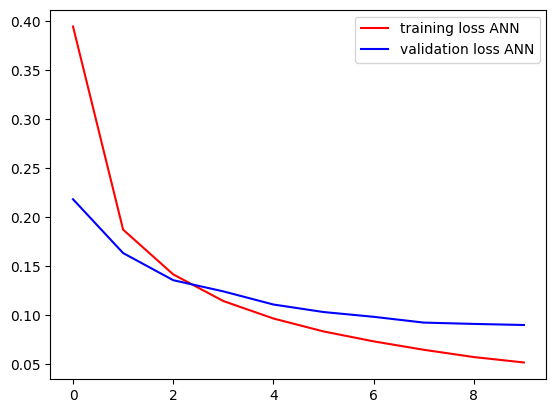

In [6]:
import matplotlib.pyplot as plt

epochs = range(10)

loss_m = history_m.history['loss']
val_loss_m = history_m.history['val_loss']

plt.plot(epochs,loss_m,'r',label='training loss ANN')
plt.plot(epochs,val_loss_m,'b',label='validation loss ANN')
plt.legend()

In [7]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_m.h5')

pred = model_simpan.predict(X_test_m)
print('label actual:',np.argmax(y_test_m[30]))
print('label prediction:',np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


In [8]:
model_m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

# HOMEWORK

In [9]:
from keras.regularizers import L1, L2, L1L2
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.utils import to_categorical

## Data Prep

reshape images

In [10]:
(X_train_g, y_train_g), (X_test_g, y_test_g) = mnist.load_data()

In [11]:
X_train_g = X_train_g.reshape(-1, 28,28,1)
X_test_g = X_test_g.reshape(-1, 28,28,1)

X_train_g = X_train_g.astype('float32')
X_test_g = X_test_g.astype('float32')

X_train_g /= 255
X_test_g /= 255

y_train = keras.utils.to_categorical(y_train_g, 10)
y_test = keras.utils.to_categorical(y_test_g, 10)

In [12]:
print('shape of X before: ', X_train_g.shape, X_test_g.shape)

X_train_g = X_train_g.reshape(-1,28*28)
X_test_g  = X_test_g.reshape(-1,28*28)

print('shape of X after: ', X_train_g.shape, X_test_g.shape)

shape of X before:  (60000, 28, 28, 1) (10000, 28, 28, 1)
shape of X after:  (60000, 784) (10000, 784)


In [13]:
Y_train_g = to_categorical(y_train_g, 10)
Y_test_g = to_categorical(y_test_g, 10)

## L1 Regularization

In [15]:
# Initiate the model
model_reg = Sequential()
model_reg.add(Flatten())
model_reg.add(Dense(64, activation='relu',kernel_regularizer= L1(0.0001)))
model_reg.add(Dense(10, activation='softmax'))

# Compile the model
model_reg.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Fit model on training data
history_reg = model_reg.fit(X_train_g, Y_train_g, validation_split=.1,
          batch_size=100, epochs=10, verbose=1)

# Evaluate model
score = model_reg.evaluate(X_test_g, Y_test_g, verbose=0)
print('Test Loss: %.4f,  Test Accuracy :%.4f' % (score[0],score[1]))

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8804 - loss: 0.5669 - val_accuracy: 0.9457 - val_loss: 0.3248
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9361 - loss: 0.3388 - val_accuracy: 0.9575 - val_loss: 0.2707
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9482 - loss: 0.2845 - val_accuracy: 0.9662 - val_loss: 0.2346
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9573 - loss: 0.2499 - val_accuracy: 0.9698 - val_loss: 0.2124
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9624 - loss: 0.2275 - val_accuracy: 0.9697 - val_loss: 0.2015
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9657 - loss: 0.2110 - val_accuracy: 0.9762 - val_loss: 0.1870
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9695 - loss: 0.1979 - val_accuracy: 0.9752 - val_loss: 0.1814
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9714 - loss: 0.1887 - val_accuracy: 

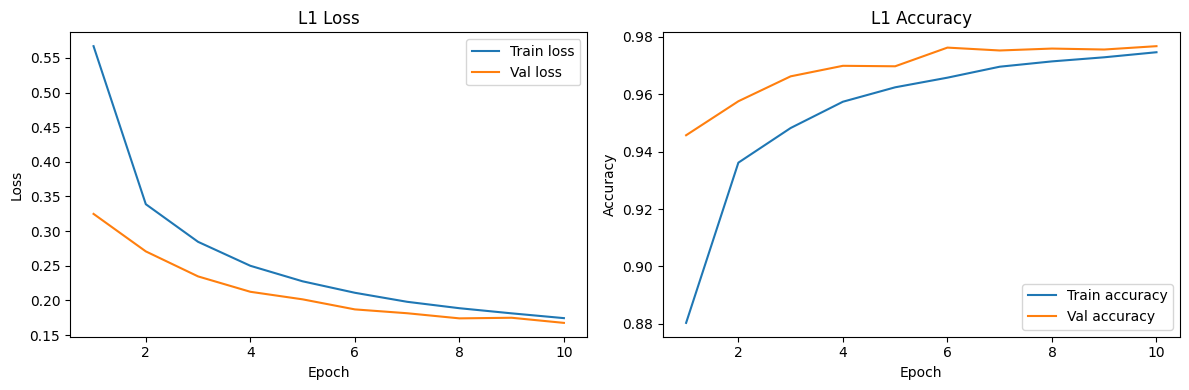

In [52]:
import matplotlib.pyplot as plt

loss_reg = history_reg.history['loss']
val_loss_reg = history_reg.history['val_loss']
acc_reg = history_reg.history['accuracy']
val_acc_reg = history_reg.history['val_accuracy']

epochs = range(1, len(loss_reg) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Column 1: loss
ax[0].plot(epochs, loss_reg, label='Train loss')
ax[0].plot(epochs, val_loss_reg, label='Val loss')
ax[0].set_title('L1 Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Column 2: accuracy
ax[1].plot(epochs, acc_reg, label='Train accuracy')
ax[1].plot(epochs, val_acc_reg, label='Val accuracy')
ax[1].set_title('L1 Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [17]:
model_reg.save("my_model_reg.h5")

In [18]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_reg.h5')

pred = model_simpan.predict(X_test_g)
print('label actual:',np.argmax(Y_test_g[30]))
print('label prediction:',np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


In [19]:
model_reg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

## L2 Regularization

In [20]:
# Initiate the model
model_reg2 = Sequential()
model_reg2.add(Flatten())
model_reg2.add(Dense(64, activation='relu',kernel_regularizer= L2(0.001)))
model_reg2.add(Dense(10, activation='softmax'))

# Compile the model
model_reg2.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Fit model on training data
history_reg2 = model_reg2.fit(X_train_g, Y_train_g, validation_split=.1,
          batch_size=100, epochs=10, verbose=1)

# Evaluate model
score = model_reg2.evaluate(X_test_g, Y_test_g, verbose=0)
print('Test Loss: %.4f,  Test Accuracy :%.4f' % (score[0],score[1]))

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8834 - loss: 0.5065 - val_accuracy: 0.9413 - val_loss: 0.2882
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9368 - loss: 0.3003 - val_accuracy: 0.9557 - val_loss: 0.2352
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9492 - loss: 0.2516 - val_accuracy: 0.9643 - val_loss: 0.2056
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9555 - loss: 0.2241 - val_accuracy: 0.9652 - val_loss: 0.1943
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9604 - loss: 0.2052 - val_accuracy: 0.9677 - val_loss: 0.1834
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9650 - loss: 0.1906 - val_accuracy: 0.9725 - val_loss: 0.1681
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9665 - loss: 0.1795 - val_accuracy: 0.9713 - val_loss: 0.1668
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9691 - loss: 0.1701 - val_accuracy: 0.

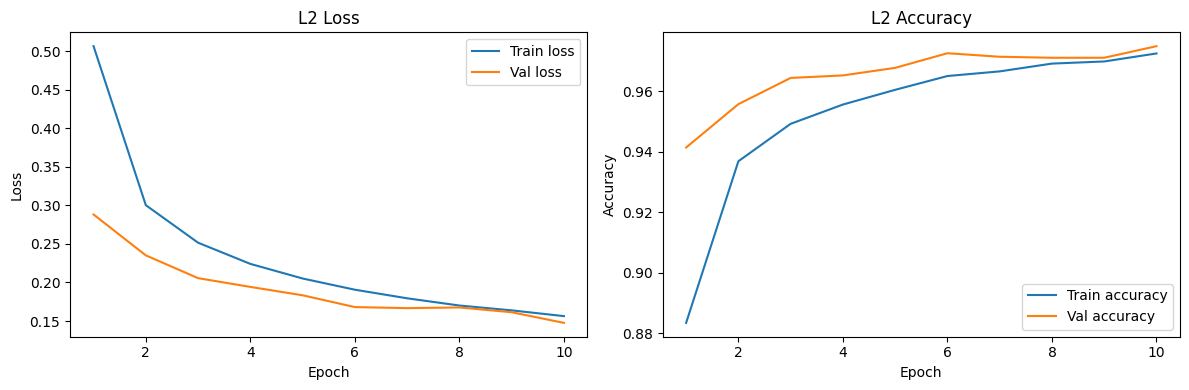

In [54]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

loss_reg2 = history_reg2.history['loss']
val_loss_reg2 = history_reg2.history['val_loss']
acc_reg2 = history_reg2.history['accuracy']
val_acc_reg2 = history_reg2.history['val_accuracy']

epochs = range(1, len(loss_reg2) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Column 1: loss
ax[0].plot(epochs, loss_reg2, label='Train loss')
ax[0].plot(epochs, val_loss_reg2, label='Val loss')
ax[0].set_title('L2 Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Column 2: accuracy
ax[1].plot(epochs, acc_reg2, label='Train accuracy')
ax[1].plot(epochs, val_acc_reg2, label='Val accuracy')
ax[1].set_title('L2 Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()


In [22]:
model_reg2.save("my_model_reg2.h5")

In [23]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_reg2.h5')

pred = model_simpan.predict(X_test_g)
print('label actual:',np.argmax(Y_test_g[30]))
print('label prediction:',np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 3
label prediction: 3


In [24]:
model_reg2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

## Dropout

In [25]:
# Initiate the model
model_do = Sequential()
model_do.add(Flatten())
model_do.add(Dense(64, activation='relu'))
model_do.add(Dropout(0.3))
model_do.add(Dense(10, activation='softmax'))

# Compile the model
model_do.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Fit model on training data
history_do = model_do.fit(X_train_g, Y_train_g, validation_split=.1,
          batch_size=100, epochs=10, verbose=1)

# Evaluate model
score = model_do.evaluate(X_test_g, Y_test_g, verbose=0)
print('Test Loss: %.4f,  Test Accuracy :%.4f' % (score[0],score[1]))

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8424 - loss: 0.5451 - val_accuracy: 0.9472 - val_loss: 0.2008
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9169 - loss: 0.2873 - val_accuracy: 0.9570 - val_loss: 0.1533
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9315 - loss: 0.2348 - val_accuracy: 0.9640 - val_loss: 0.1272
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9408 - loss: 0.2020 - val_accuracy: 0.9683 - val_loss: 0.1100
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9449 - loss: 0.1820 - val_accuracy: 0.9708 - val_loss: 0.1037
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9498 - loss: 0.1689 - val_accuracy: 0.9710 - val_loss: 0.0982
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9529 - loss: 0.1564 - val_accuracy: 0.9723 - val_loss: 0.0937
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9541 - loss: 0.1484 - val_accuracy: 0.

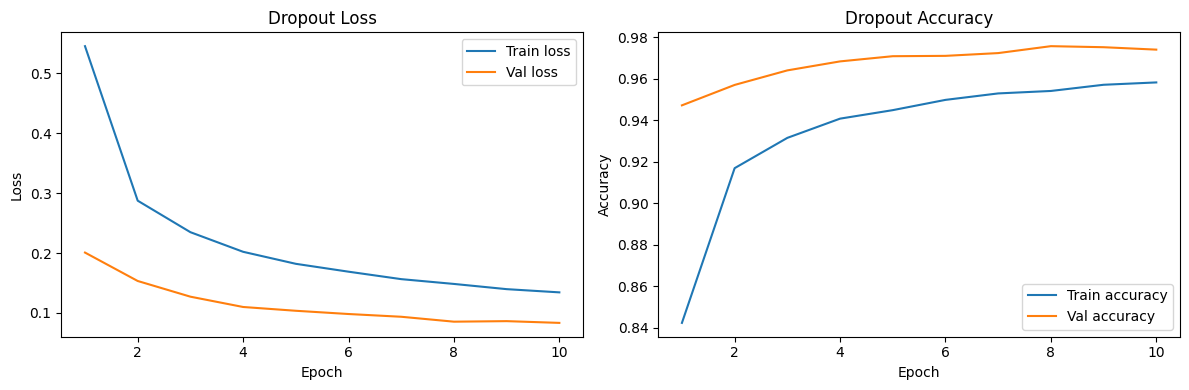

In [56]:
import matplotlib.pyplot as plt

loss_do = history_do.history['loss']
val_loss_do = history_do.history['val_loss']
acc_do = history_do.history['accuracy']
val_acc_do = history_do.history['val_accuracy']

epochs = range(1, len(loss_do) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Column 1: loss
ax[0].plot(epochs, loss_do, label='Train loss')
ax[0].plot(epochs, val_loss_do, label='Val loss')
ax[0].set_title('Dropout Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Column 2: accuracy
ax[1].plot(epochs, acc_do, label='Train accuracy')
ax[1].plot(epochs, val_acc_do, label='Val accuracy')
ax[1].set_title('Dropout Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [27]:
model_do.save("my_model_do.h5")

In [28]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_do.h5')

pred = model_simpan.predict(X_test_g)
print('label actual:',np.argmax(Y_test_g[45]))
print('label prediction:',np.argmax(pred[45]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 5
label prediction: 5


In [29]:
model_do.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

## Early Stopping

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [34]:
# Initiate the model
model_es = Sequential()
model_es.add(Flatten())
model_es.add(Dense(64, activation='relu'))
model_es.add(Dense(10, activation='softmax'))

# Compile the model
model_es.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Fit model on training data
history_es = model_es.fit(X_train_g, Y_train_g, validation_split=.1,
          batch_size=100, epochs=50, verbose=1, callbacks = [early_stop])

# Evaluate model
score = model_es.evaluate(X_test_g, Y_test_g, verbose=0)
print('Test Loss: %.4f,  Test Accuracy :%.4f' % (score[0],score[1]))
print('Stopped at epoch:', len(history_es.history['loss']))

Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8879 - loss: 0.4124 - val_accuracy: 0.9503 - val_loss: 0.1888
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9433 - loss: 0.1977 - val_accuracy: 0.9627 - val_loss: 0.1406
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9571 - loss: 0.1503 - val_accuracy: 0.9683 - val_loss: 0.1209
Epoch 4/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9642 - loss: 0.1241 - val_accuracy: 0.9712 - val_loss: 0.1091
Epoch 5/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9698 - loss: 0.1048 - val_accuracy: 0.9708 - val_loss: 0.1040
Epoch 6/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0907 - val_accuracy: 0.9720 - val_loss: 0.1017
Epoch 7/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9774 - loss: 0.0793 - val_accuracy: 0.9742 - val_loss: 0.0934
Epoch 8/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9794 - loss: 0.0707 - val_accuracy: 0.

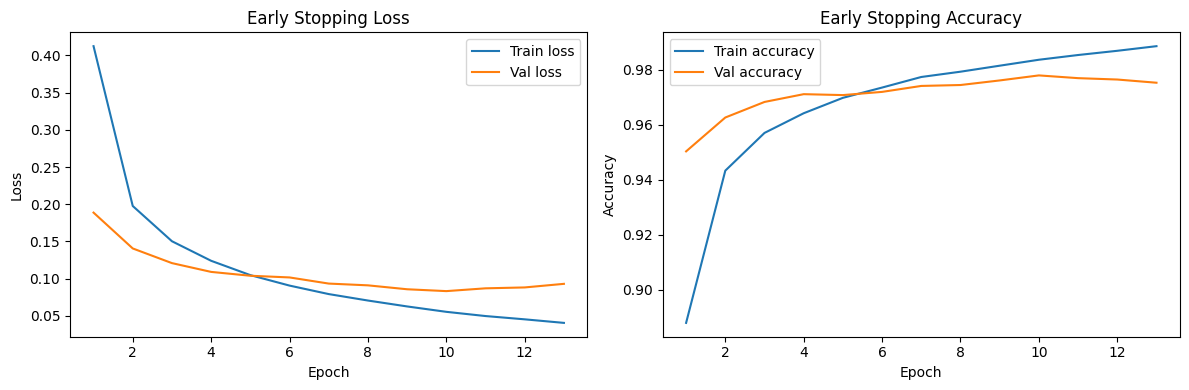

In [57]:
import matplotlib.pyplot as plt

loss_es = history_es.history['loss']
val_loss_es = history_es.history['val_loss']
acc_es = history_es.history['accuracy']
val_acc_es = history_es.history['val_accuracy']

epochs = range(1, len(loss_es) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Column 1: loss
ax[0].plot(epochs, loss_es, label='Train loss')
ax[0].plot(epochs, val_loss_es, label='Val loss')
ax[0].set_title('Early Stopping Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Column 2: accuracy
ax[1].plot(epochs, acc_es, label='Train accuracy')
ax[1].plot(epochs, val_acc_es, label='Val accuracy')
ax[1].set_title('Early Stopping Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [37]:
model_es.save("my_model_es.h5")

In [38]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_es.h5')

pred = model_simpan.predict(X_test_g)
print('label actual:',np.argmax(Y_test_g[100]))
print('label prediction:',np.argmax(pred[100]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 6
label prediction: 6


In [39]:
model_es.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

## L1 + Dropout

In [40]:
# Initiate the model
model_l1do = Sequential()
model_l1do.add(Flatten())
model_l1do.add(Dense(64, activation='relu', kernel_regularizer=L1(0.0001)))
model_l1do.add(Dropout(0.3))
model_l1do.add(Dense(10, activation='softmax'))

# Compile the model
model_l1do.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Fit model on training data
history_l1do = model_l1do.fit(X_train_g, Y_train_g, validation_split=.1,
          batch_size=100, epochs=10, verbose=1)

# Evaluate model
score = model_l1do.evaluate(X_test_g, Y_test_g, verbose=0)
print('Test Loss: %.4f,  Test Accuracy :%.4f' % (score[0],score[1]))


Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8392 - loss: 0.6842 - val_accuracy: 0.9405 - val_loss: 0.3370
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9103 - loss: 0.4275 - val_accuracy: 0.9560 - val_loss: 0.2780
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9243 - loss: 0.3704 - val_accuracy: 0.9632 - val_loss: 0.2487
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9340 - loss: 0.3343 - val_accuracy: 0.9693 - val_loss: 0.2261
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9378 - loss: 0.3162 - val_accuracy: 0.9693 - val_loss: 0.2154
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9416 - loss: 0.2995 - val_accuracy: 0.9705 - val_loss: 0.2089
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9447 - loss: 0.2865 - val_accuracy: 0.9730 - val_loss: 0.1982
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9462 - loss: 0.2790 - val_accuracy: 0.

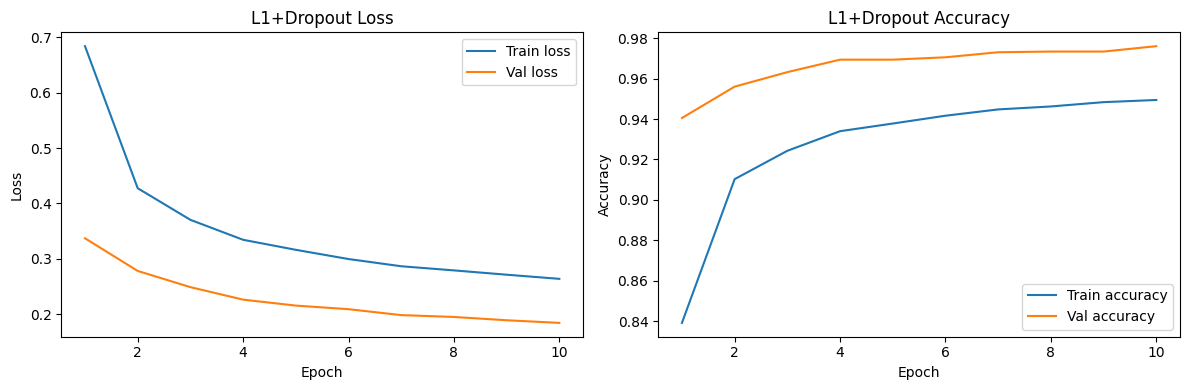

In [58]:
import matplotlib.pyplot as plt

loss_l1do = history_l1do.history['loss']
val_loss_l1do = history_l1do.history['val_loss']
acc_l1do = history_l1do.history['accuracy']
val_acc_l1do = history_l1do.history['val_accuracy']

epochs = range(1, len(loss_l1do) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Column 1: loss
ax[0].plot(epochs, loss_l1do, label='Train loss')
ax[0].plot(epochs, val_loss_l1do, label='Val loss')
ax[0].set_title('L1+Dropout Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Column 2: accuracy
ax[1].plot(epochs, acc_l1do, label='Train accuracy')
ax[1].plot(epochs, val_acc_l1do, label='Val accuracy')
ax[1].set_title('L1+Dropout Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [42]:
model_l1do.save("my_model_l1do.h5")

In [43]:
import numpy as np
from keras.models import load_model

model_simpan = load_model('my_model_l1do.h5')

pred = model_simpan.predict(X_test_g)
print('label actual:',np.argmax(Y_test_g[100]))
print('label prediction:',np.argmax(pred[100]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label actual: 6
label prediction: 6


In [44]:
model_l1do.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

## History Result

In [70]:
import pandas as pd

histories = {
    'L1': history_reg,
    'L2': history_reg2,
    'Dropout': history_do,
    #'Early Stopping': history_es, -> karena early stopping, dia cuma ngambil nilai terakhir aja (ga akurat)
    'L1 + Dropout': history_l1do,
}

rows = []
for name, h in histories.items():
    rows.append({
        'Method': name,
        'Train loss': h.history['loss'][-1],
        'Val loss': h.history['val_loss'][-1],
        'Train acc': h.history['accuracy'][-1],
        'Val acc': h.history['val_accuracy'][-1],
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

      Method  Train loss  Val loss  Train acc  Val acc
          L1      0.1744    0.1675     0.9746   0.9767
          L2      0.1564    0.1476     0.9724   0.9748
     Dropout      0.1344    0.0835     0.9582   0.9740
L1 + Dropout      0.2637    0.1841     0.9494   0.9760


In [69]:
import numpy as np

best_es = np.argmin(history_es.history['val_loss'])

print("Early Stopping History")
print("----")
print('Best epoch   :', best_es + 1)
print('Loss         :', history_es.history['loss'][best_es])
print('Accuracy     :', history_es.history['accuracy'][best_es])
print('Val loss     :', history_es.history['val_loss'][best_es])
print('Val accuracy :', history_es.history['val_accuracy'][best_es])

Early Stopping History
----
Best epoch   : 10
Loss         : 0.05547678470611572
Accuracy     : 0.9837037324905396
Val loss     : 0.08331148326396942
Val accuracy : 0.9779999852180481
